In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
precios = pd.read_csv('../data/precios_historicos.csv', index_col='Date', parse_dates=True)
tickers = precios.columns.tolist()
retornos_diarios = precios.pct_change().dropna()

In [3]:
tasa_libre_riesgo = 0.05

In [4]:
dias_trading = 252

print("Tickers:", tickers)
print(f"Tasa libre de riesgo asumida: {tasa_libre_riesgo*100}% anual")

Tickers: ['GGAL', 'MELI', 'SPY', 'YPF']
Tasa libre de riesgo asumida: 5.0% anual


In [5]:
volatilidad_anual = retornos_diarios.std() * np.sqrt(dias_trading)

print("\nVolatilidad anualizada (%):")
print((volatilidad_anual * 100).round(2))


Volatilidad anualizada (%):
GGAL    63.52
MELI    39.15
SPY     15.26
YPF     54.49
dtype: float64


In [6]:
retorno_anual = retornos_diarios.mean() * dias_trading

print("\nRetorno anualizado (%):")
print((retorno_anual * 100).round(2))


Retorno anualizado (%):
GGAL    64.88
MELI    18.15
SPY     20.35
YPF     55.87
dtype: float64


In [7]:
sharpe_ratio = (retorno_anual - tasa_libre_riesgo) / volatilidad_anual

print("\nRatio Sharpe:")
print(sharpe_ratio.round(2))


Ratio Sharpe:
GGAL    0.94
MELI    0.34
SPY     1.01
YPF     0.93
dtype: float64


In [8]:
nivel_confianza = 0.95
var_95 = retornos_diarios.quantile(1 - nivel_confianza)

print(f"\nValue at Risk (VaR) al {int(nivel_confianza*100)}% (retorno diario, %):")
print((var_95 * 100).round(2))
print("(Interpretación: en el 5% de los peores días, la pérdida diaria")
print("puede superar este porcentaje)")


Value at Risk (VaR) al 95% (retorno diario, %):
GGAL   -5.24
MELI   -3.58
SPY    -1.42
YPF    -4.44
Name: 0.050000000000000044, dtype: float64
(Interpretación: en el 5% de los peores días, la pérdida diaria
puede superar este porcentaje)


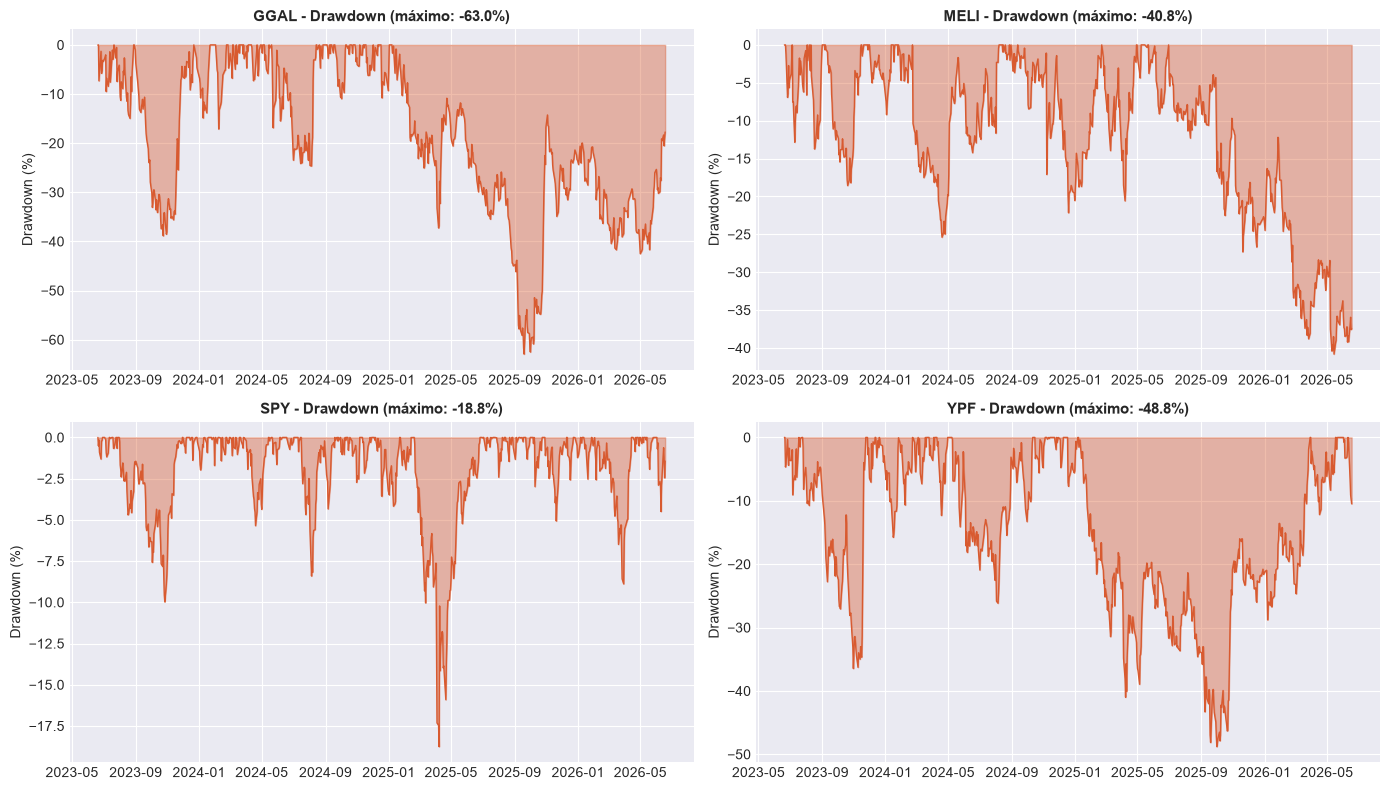


Máximo Drawdown por activo (%):
GGAL   -62.95
MELI   -40.82
SPY    -18.76
YPF    -48.79
dtype: float64


In [9]:
def calcular_drawdown(precios_serie):
    """Calcula la serie de drawdown y el máximo drawdown de una serie de precios."""
    acumulado_max = precios_serie.cummax()           # El máximo histórico hasta cada punto
    drawdown = (precios_serie - acumulado_max) / acumulado_max  # Caída relativa desde el máximo
    max_drawdown = drawdown.min()                      # El peor drawdown del período
    return drawdown, max_drawdown

max_drawdowns = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    drawdown_serie, max_dd = calcular_drawdown(precios[ticker])
    max_drawdowns[ticker] = max_dd

    axes[i].fill_between(drawdown_serie.index, drawdown_serie * 100, 0,
                          color='#D85A30', alpha=0.4)
    axes[i].plot(drawdown_serie.index, drawdown_serie * 100, color='#D85A30', linewidth=1)
    axes[i].set_title(f'{ticker} - Drawdown (máximo: {max_dd*100:.1f}%)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Drawdown (%)')

plt.tight_layout()
plt.savefig('../data/drawdown.png', dpi=150)
plt.show()

max_drawdowns = pd.Series(max_drawdowns)
print("\nMáximo Drawdown por activo (%):")
print((max_drawdowns * 100).round(2))

In [10]:
tabla_resumen = pd.DataFrame({
    'Retorno anual (%)': (retorno_anual * 100).round(2),
    'Volatilidad anual (%)': (volatilidad_anual * 100).round(2),
    'Ratio Sharpe': sharpe_ratio.round(2),
    'VaR 95% diario (%)': (var_95 * 100).round(2),
    'Max Drawdown (%)': (max_drawdowns * 100).round(2)
})

print("\n" + "="*70)
print("TABLA RESUMEN - MÉTRICAS DE RIESGO")
print("="*70)
print(tabla_resumen)

# Guardamos la tabla para reutilizarla en el notebook de optimización
tabla_resumen.to_csv('../data/metricas_riesgo.csv')

print("\n✅ Notebook 3 completo. Listo para la optimización de portafolio (Notebook 4).")


TABLA RESUMEN - MÉTRICAS DE RIESGO
      Retorno anual (%)  Volatilidad anual (%)  Ratio Sharpe  \
GGAL              64.88                  63.52          0.94   
MELI              18.15                  39.15          0.34   
SPY               20.35                  15.26          1.01   
YPF               55.87                  54.49          0.93   

      VaR 95% diario (%)  Max Drawdown (%)  
GGAL               -5.24            -62.95  
MELI               -3.58            -40.82  
SPY                -1.42            -18.76  
YPF                -4.44            -48.79  

✅ Notebook 3 completo. Listo para la optimización de portafolio (Notebook 4).


## Observaciones

- El activo con mejor ratio Sharpe fue SPY (1.01), seguido muy de cerca por
  GGAL (0.94) y YPF (0.93). Esto resulta llamativo: SPY logra una relación
  riesgo/retorno prácticamente equivalente a las acciones argentinas, pero
  asumiendo una fracción de su volatilidad (15.26% vs. 63.52% y 54.49%).

- GGAL presentó tanto la mayor volatilidad anualizada (63.52%) como el
  mayor drawdown máximo del portafolio (-62.95%), lo cual es consistente
  con el perfil de riesgo elevado típico de una acción individual de un
  mercado emergente, frente a la estabilidad relativa de un índice
  diversificado como SPY (drawdown de solo -18.76%).

- MELI fue el único activo con un ratio Sharpe considerablemente más bajo
  (0.34) a pesar de tener una volatilidad intermedia (39.15%), lo que
  indica que su retorno obtenido no compensó adecuadamente el riesgo
  asumido durante este período específico.